# Edge IIoT - Sliding Window Statistics

## 0. Imports & Configuration

In [1]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

import sys
import itertools
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, classification_report, confusion_matrix
)

from src.config import DATASETS, SEED

np.random.seed(SEED)

In [2]:
WINDOW_SIZES = [20, 40, 80, 120, 200, 320, 520]
STEP_FRACS   = {'full': 1.0, 'half': 0.5, 'quarter': 0.25}
AGG_FNS      = ['mean', 'max', 'median']   # how window features are summarised before z-scoring
NORMS        = ['L1', 'L2', 'Linf']        # vector norm used as anomaly score
BASELINES    = ['global', 'percentile90']  # how baseline mean/std are estimated

print('Hyperparameter grid:')
print(f'  Window sizes : {WINDOW_SIZES}')
print(f'  Step fracs   : {list(STEP_FRACS.keys())}')
print(f'  Agg fns      : {AGG_FNS}')
print(f'  Norms        : {NORMS}')
print(f'  Baselines    : {BASELINES}')

total = len(WINDOW_SIZES) * len(STEP_FRACS) * len(AGG_FNS) * len(NORMS) * len(BASELINES)
print(f'\nTotal configurations: {total}')

Hyperparameter grid:
  Window sizes : [20, 40, 80, 120, 200, 320, 520]
  Step fracs   : ['full', 'half', 'quarter']
  Agg fns      : ['mean', 'max', 'median']
  Norms        : ['L1', 'L2', 'Linf']
  Baselines    : ['global', 'percentile90']

Total configurations: 378


## 1.Preprocessing

### Data Loading

In [3]:
dataset_name = 'edge_iiot'
config       = DATASETS[dataset_name]

filename = 'DNN-EdgeIIoT-dataset'
csv_path = config['processed_path'] / f'{filename}.pkl'

print('Loading dataset...')
df = pd.read_pickle(csv_path)
print(f'Dataset shape : {df.shape}')

target = 'Attack_type'
y_bin  = df['Attack_label'].values   # 0=Normal, 1=Attack
y_15c   = df[target].values
df     = df.drop(columns=['Attack_label'])

X = df.drop(columns=[target])

# Drop env-specific cols
cols_to_drop = [
    'frame.time.delta', 'frame.time.order',
    *[c for c in X.columns if c.startswith('ip.src_category')
                             or c.startswith('ip.dst_category')]
]
X = X.drop(columns=cols_to_drop, errors='ignore')

# Keep only numeric columns
X_numeric    = X.select_dtypes(include=['number'])
feature_names = list(X_numeric.columns)

print(f'Numeric features : {X_numeric.shape[1]}')
print(f'Total samples    : {len(y_bin):,}')
print(f'Attack rate      : {y_bin.mean():.3f}')
print(f'\nClass distribution:')
print(pd.Series(y_15c).value_counts().to_string())

Loading dataset...
Dataset shape : (2158750, 62)
Numeric features : 43
Total samples    : 2,158,750
Attack rate      : 0.252

Class distribution:
Normal                   1615642
DDoS_UDP                  121568
DDoS_ICMP                  77086
SQL_injection              51203
Password                   50153
Vulnerability_scanner      50107
DDoS_HTTP                  49911
Uploading                  37634
DDoS_TCP                   29155
Backdoor                   24862
Port_Scanning              22564
XSS                        15913
Ransomware                 10923
MITM                        1028
Fingerprinting              1001


### Train / Test Split

In [4]:
n = len(X_numeric)
split = int(n * 0.8)

idx_train = np.arange(0, split)
idx_test  = np.arange(split, n)

X_train_raw = X_numeric.iloc[idx_train].values
X_test_raw  = X_numeric.iloc[idx_test].values
y_bin_train = y_bin[idx_train]
y_bin_test  = y_bin[idx_test]
y_15c_train  = y_15c[idx_train]
y_15c_test   = y_15c[idx_test]

print(f'Train stream : {X_train_raw.shape}  attack rate={y_bin_train.mean():.3f}')
print(f'Test  stream : {X_test_raw.shape}   attack rate={y_bin_test.mean():.3f}')

Train stream : (1727000, 43)  attack rate=0.173
Test  stream : (431750, 43)   attack rate=0.566


In [5]:
comparison = pd.DataFrame({
    'train': pd.Series(y_15c_train).value_counts(),
    'test':  pd.Series(y_15c_test).value_counts(),
}).sort_index().fillna(0).astype(int)

comparison['train_%'] = (comparison['train'] / comparison['train'].sum() * 100).round(1)
comparison['test_%']  = (comparison['test']  / comparison['test'].sum()  * 100).round(1)

print(comparison.to_string())

                         train    test  train_%  test_%
Backdoor                 24862       0      1.4     0.0
DDoS_HTTP                49911       0      2.9     0.0
DDoS_ICMP                    0   77086      0.0    17.9
DDoS_TCP                 29155       0      1.7     0.0
DDoS_UDP                     0  121568      0.0    28.2
Fingerprinting               0    1001      0.0     0.2
MITM                         0    1028      0.0     0.2
Normal                 1428122  187520     82.7    43.4
Password                 50153       0      2.9     0.0
Port_Scanning            22564       0      1.3     0.0
Ransomware                5010    5913      0.3     1.4
SQL_injection            51203       0      3.0     0.0
Uploading                    0   37634      0.0     8.7
Vulnerability_scanner    50107       0      2.9     0.0
XSS                      15913       0      0.9     0.0


> Cannot use this split due to unbalanced data


In [6]:
# Divide in N blocks and divide stratified
N_BLOCKS = 10000
block_size = len(X_numeric) // N_BLOCKS
block_ids = np.repeat(np.arange(N_BLOCKS), block_size)
block_ids = np.append(block_ids, np.full(len(X_numeric) - len(block_ids), N_BLOCKS - 1))

block_labels = np.array([
    pd.Series(y_15c[block_ids == b]).mode()[0]
    for b in range(N_BLOCKS)
])

block_idx = np.arange(N_BLOCKS)
train_blocks, test_blocks = train_test_split(
    block_idx, test_size=0.2, random_state=SEED, stratify=block_labels
)

idx_train = np.sort(np.where(np.isin(block_ids, train_blocks))[0])
idx_test  = np.sort(np.where(np.isin(block_ids, test_blocks))[0])

X_train_raw = X_numeric.iloc[idx_train].values
X_test_raw  = X_numeric.iloc[idx_test].values
y_bin_train = y_bin[idx_train]
y_bin_test  = y_bin[idx_test]
y_15c_train  = y_15c[idx_train]
y_15c_test   = y_15c[idx_test]

print(f'Train stream : {X_train_raw.shape}  attack rate={y_bin_train.mean():.3f}')
print(f'Test  stream : {X_test_raw.shape}   attack rate={y_bin_test.mean():.3f}')

Train stream : (1728750, 43)  attack rate=0.252
Test  stream : (430000, 43)   attack rate=0.249


In [7]:
comparison = pd.DataFrame({
    'train': pd.Series(y_15c_train).value_counts(),
    'test':  pd.Series(y_15c_test).value_counts(),
}).sort_index().fillna(0).astype(int)

comparison['train_%'] = (comparison['train'] / comparison['train'].sum() * 100).round(1)
comparison['test_%']  = (comparison['test']  / comparison['test'].sum()  * 100).round(1)

print(comparison.to_string())

                         train    test  train_%  test_%
Backdoor                 19889    4973      1.2     1.2
DDoS_HTTP                40021    9890      2.3     2.3
DDoS_ICMP                61734   15352      3.6     3.6
DDoS_TCP                 22619    6536      1.3     1.5
DDoS_UDP                 99050   22518      5.7     5.2
Fingerprinting             832     169      0.0     0.0
MITM                       860     168      0.0     0.0
Normal                 1292677  322965     74.8    75.1
Password                 40147   10006      2.3     2.3
Port_Scanning            18138    4426      1.0     1.0
Ransomware                8573    2350      0.5     0.5
SQL_injection            41110   10093      2.4     2.3
Uploading                29867    7767      1.7     1.8
Vulnerability_scanner    40573    9534      2.3     2.2
XSS                      12660    3253      0.7     0.8


### Scaling

In [8]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(pd.DataFrame(X_train_raw, columns=feature_names))
X_test_scaled  = scaler.transform(pd.DataFrame(X_test_raw, columns=feature_names))

print(f'Scaled train : {X_train_scaled.shape}')
print(f'Scaled test  : {X_test_scaled.shape}')

Scaled train : (1728750, 43)
Scaled test  : (430000, 43)


## 2. Architecture

### Utility Functions

In [9]:
def make_windows(X: np.ndarray, W: int, step: int) -> np.ndarray:
    """Sliding windows over a 2D array (T, F) -> (n_windows, W, F)"""
    n   = (len(X) - W) // step + 1
    idx = np.arange(W)[None, :] + step * np.arange(n)[:, None]
    return X[idx]   # (n_windows, W, n_features)


def window_labels(y: np.ndarray, W: int, step: int,
                  mode: str = 'any') -> np.ndarray:
    """Labels per window."""
    n       = (len(y) - W) // step + 1
    idx     = np.arange(W)[None, :] + step * np.arange(n)[:, None]
    windows = y[idx]
    if mode == 'any':
        return (windows.sum(axis=1) > 0).astype(int)
    elif mode == 'last':
        return windows[:, -1].astype(int)
    else:
        return (windows.mean(axis=1) >= 0.5).astype(int)


def window_attack_types(y_15c: np.ndarray, y_bin: np.ndarray,
                        W: int, step: int) -> np.ndarray:
    """First attack type per window (returns 'Normal' if no attack present)."""
    n      = (len(y_15c) - W) // step + 1
    idx    = np.arange(W)[None, :] + step * np.arange(n)[:, None]
    result = []
    for row_idx in idx:
        attacks = y_15c[row_idx][y_bin[row_idx].astype(bool)]
        result.append(attacks[0] if len(attacks) > 0 else 'Normal')
    return np.array(result)


def optimal_threshold(y_true, scores):
    p, r, t = precision_recall_curve(y_true, scores)
    f1s     = 2 * p * r / (p + r + 1e-9)
    best    = np.argmax(f1s)
    return t[best] if best < len(t) else 0.5


def evaluate(name, y_true, scores, verbose=True):
    y_true  = np.asarray(y_true)
    scores  = np.asarray(scores, dtype=float)
    if len(np.unique(y_true)) < 2:
        return None
    auroc  = roc_auc_score(y_true, scores)
    auprc  = average_precision_score(y_true, scores)
    thresh = optimal_threshold(y_true, scores)
    y_pred = (scores >= thresh).astype(int)
    rep    = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    f1     = rep['1']['f1-score']
    pre    = rep['1']['precision']
    rec    = rep['1']['recall']
    if verbose:
        print(f'  {name:50s}  AUROC={auroc:.4f}  AUPRC={auprc:.4f}  F1={f1:.4f}')
    return dict(name=name, AUROC=auroc, AUPRC=auprc, F1=f1,
                Precision=pre, Recall=rec,
                scores=scores, threshold=thresh)


print('Utilities defined.')

Utilities defined.


### Scoring Engine

| Knob | Options | Effect |
|---|---|---|
| `agg_fn` | `mean` / `max` / `median` | How per-window features are summarised before z-scoring |
| `norm` | `L1` / `L2` / `Linf` | Which vector norm turns z-scores into a scalar anomaly score |
| `baseline` | `global` / `percentile90` | Whether the normal baseline is estimated from all normal packets or from the 10th–90th percentile range |

In [10]:
def compute_sws_scores(
    W_test: np.ndarray,
    baseline_mean: np.ndarray,
    baseline_std: np.ndarray,
    agg_fn: str = 'mean',
    norm: str = 'L2'
) -> np.ndarray:
    """Score each test window via z-score distance from the normal baseline."""
    # Aggregate window. single feature vector
    if agg_fn == 'mean':
        summary = W_test.mean(axis=1)     # (n_windows, F)
    elif agg_fn == 'max':
        summary = W_test.max(axis=1)
    elif agg_fn == 'median':
        summary = np.median(W_test, axis=1)
    else:
        raise ValueError(f'Unknown agg_fn: {agg_fn}')

    # Z-score each feature
    z = (summary - baseline_mean) / baseline_std   # (n_windows, F)

    # Scalar norm
    if norm == 'L2':
        return np.linalg.norm(z, axis=1)
    elif norm == 'L1':
        return np.abs(z).sum(axis=1)
    elif norm == 'Linf':
        return np.abs(z).max(axis=1)
    else:
        raise ValueError(f'Unknown norm: {norm}')


def estimate_baseline(
    X_normal: np.ndarray,
    method: str = 'global'
):
    """Estimate baseline (mean, std) from normal training packets."""
    if method == 'global':
        mean = X_normal.mean(axis=0)
        std  = X_normal.std(axis=0) + 1e-9
    elif method == 'percentile90':
        lo   = np.percentile(X_normal, 5,  axis=0)
        hi   = np.percentile(X_normal, 95, axis=0)
        mask = ((X_normal >= lo) & (X_normal <= hi)).all(axis=1)
        X_clipped = X_normal[mask] if mask.sum() > 100 else X_normal
        mean = X_clipped.mean(axis=0)
        std  = X_clipped.std(axis=0) + 1e-9
    else:
        raise ValueError(f'Unknown baseline method: {method}')
    return mean, std


print('SWS engine defined.')

SWS engine defined.


## 3. Execution

### Baseline Estimation

In [11]:
normal_mask_train = (y_bin_train == 0)
X_normal_train    = X_train_scaled[normal_mask_train]

baselines = {}
for method in BASELINES:
    mean, std = estimate_baseline(X_normal_train, method=method)
    baselines[method] = (mean, std)
    print(f'Baseline [{method:15s}]  mean range=[{mean.min():.3f}, {mean.max():.3f}]  '
          f'std range=[{std.min():.4f}, {std.max():.4f}]')

print(f'\nNormal training packets : {X_normal_train.shape[0]:,}')

Baseline [global         ]  mean range=[0.000, 1.000]  std range=[0.0000, 0.4392]
Baseline [percentile90   ]  mean range=[0.000, 1.000]  std range=[0.0000, 0.4355]

Normal training packets : 1,292,677


### Hyperparameter Grid Search

In [12]:
grid_results = []
t_start      = time.time()
n_configs    = 0

_label_cache = {}
_window_cache = {}

for W in WINDOW_SIZES:
    for step_name, step_frac in STEP_FRACS.items():
        # Resolve step size
        step = 1 if step_frac is None else max(1, int(W * step_frac))

        cache_key = (W, step)
        if cache_key not in _window_cache:
            W_test     = make_windows(X_test_scaled, W, step)
            y_w_test   = window_labels(y_bin_test, W, step, mode='any')
            _window_cache[cache_key] = W_test
            _label_cache[cache_key]  = y_w_test
        else:
            W_test   = _window_cache[cache_key]
            y_w_test = _label_cache[cache_key]

        if len(np.unique(y_w_test)) < 2:
            continue

        for baseline_name in BASELINES:
            bm, bs = baselines[baseline_name]

            for agg_fn in AGG_FNS:
                for norm in NORMS:
                    n_configs += 1
                    run_name   = f'W={W}_step={step_name}_agg={agg_fn}_norm={norm}_base={baseline_name}'

                    scores = compute_sws_scores(W_test, bm, bs,
                                               agg_fn=agg_fn, norm=norm)
                    res    = evaluate(run_name, y_w_test, scores, verbose=False)

                    if res is None:
                        continue

                    grid_results.append(dict(
                        W=W, step_name=step_name, step=step,
                        agg_fn=agg_fn, norm=norm, baseline=baseline_name,
                        n_windows=len(y_w_test),
                        attack_rate=float(y_w_test.mean()),
                        AUROC=res['AUROC'], AUPRC=res['AUPRC'],
                        F1=res['F1'], Precision=res['Precision'], Recall=res['Recall'],
                        threshold=res['threshold'],
                        run_name=run_name,
                    ))

elapsed = time.time() - t_start
grid_df = pd.DataFrame(grid_results)

print(f'\nGrid search complete — {n_configs} configs, {len(grid_df)} valid results  ({elapsed:.1f}s)')
print(f'\nTop-10 by AUROC:')
print(grid_df.nlargest(10, 'AUROC')[
    ['W','step_name','agg_fn','norm','baseline','AUROC','AUPRC','F1','Precision','Recall']
].to_string(index=False, float_format='{:.4f}'.format))


Grid search complete — 378 configs, 378 valid results  (55.1s)

Top-10 by AUROC:
  W step_name agg_fn norm baseline  AUROC  AUPRC     F1  Precision  Recall
520      full   mean   L2   global 0.9754 0.9934 0.9683     0.9867  0.9505
520   quarter   mean   L2   global 0.9742 0.9932 0.9669     0.9843  0.9501
520      half   mean   L2   global 0.9738 0.9931 0.9675     0.9867  0.9489
320   quarter   mean   L2   global 0.9677 0.9912 0.9627     0.9752  0.9504
520      half    max   L2   global 0.9656 0.9902 0.9493     0.9357  0.9633
320      half   mean   L2   global 0.9656 0.9907 0.9616     0.9737  0.9497
520      full    max   L2   global 0.9652 0.9900 0.9497     0.9350  0.9649
320      full   mean   L2   global 0.9649 0.9906 0.9600     0.9746  0.9459
520      half    max   L1   global 0.9643 0.9897 0.9493     0.9357  0.9633
520   quarter    max   L2   global 0.9641 0.9897 0.9480     0.9335  0.9629


## 4. Results

### Comparison Table

In [13]:
display_cols = ['W', 'step_name', 'agg_fn', 'norm', 'baseline',
                'n_windows', 'attack_rate',
                'AUROC', 'AUPRC', 'F1', 'Precision', 'Recall']

top_df = grid_df.nlargest(30, 'AUROC')[display_cols].reset_index(drop=True)

print('Top-30 configurations by AUROC:')
print(top_df.to_string(float_format='{:.4f}'.format))

Top-30 configurations by AUROC:
      W step_name agg_fn  norm baseline  n_windows  attack_rate  AUROC  AUPRC     F1  Precision  Recall
0   520      full   mean    L2   global        826       0.7579 0.9754 0.9934 0.9683     0.9867  0.9505
1   520   quarter   mean    L2   global       3304       0.7588 0.9742 0.9932 0.9669     0.9843  0.9501
2   520      half   mean    L2   global       1652       0.7585 0.9738 0.9931 0.9675     0.9867  0.9489
3   320   quarter   mean    L2   global       5372       0.7550 0.9677 0.9912 0.9627     0.9752  0.9504
4   520      half    max    L2   global       1652       0.7585 0.9656 0.9902 0.9493     0.9357  0.9633
5   320      half   mean    L2   global       2686       0.7554 0.9656 0.9907 0.9616     0.9737  0.9497
6   520      full    max    L2   global        826       0.7579 0.9652 0.9900 0.9497     0.9350  0.9649
7   320      full   mean    L2   global       1343       0.7565 0.9649 0.9906 0.9600     0.9746  0.9459
8   520      half    max    L1  

### Hyperparameter effects

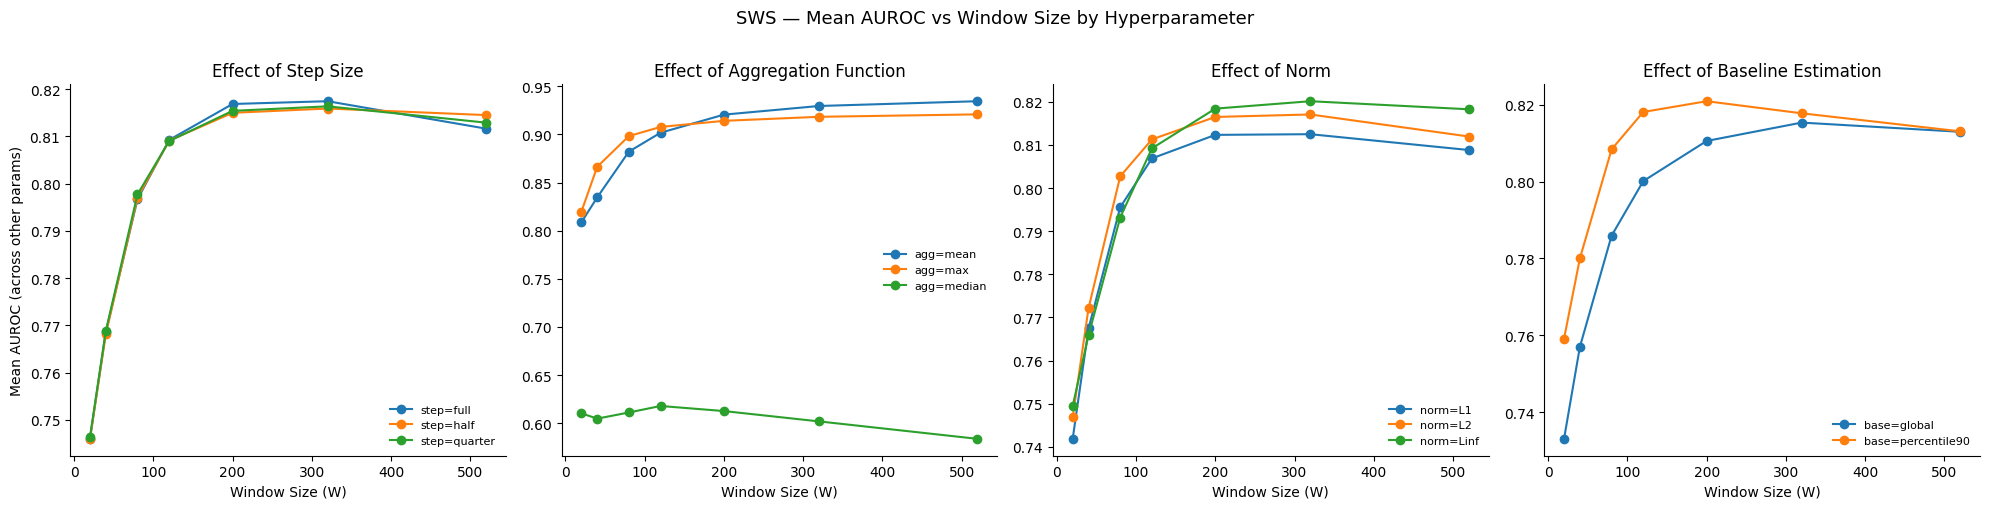

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# By step fraction
ax = axes[0]
for step_name in STEP_FRACS:
    sub = grid_df[grid_df['step_name'] == step_name].groupby('W')['AUROC'].mean()
    ax.plot(sub.index, sub.values, marker='o', label=f'step={step_name}')
ax.set_xlabel('Window Size (W)')
ax.set_ylabel('Mean AUROC (across other params)')
ax.set_title('Effect of Step Size')
ax.legend(fontsize=8, frameon=False)
sns.despine(ax=ax)

# By aggregation function
ax = axes[1]
for agg in AGG_FNS:
    sub = grid_df[grid_df['agg_fn'] == agg].groupby('W')['AUROC'].mean()
    ax.plot(sub.index, sub.values, marker='o', label=f'agg={agg}')
ax.set_xlabel('Window Size (W)')
ax.set_title('Effect of Aggregation Function')
ax.legend(fontsize=8, frameon=False)
sns.despine(ax=ax)

# By norm
ax = axes[2]
for norm in NORMS:
    sub = grid_df[grid_df['norm'] == norm].groupby('W')['AUROC'].mean()
    ax.plot(sub.index, sub.values, marker='o', label=f'norm={norm}')
ax.set_xlabel('Window Size (W)')
ax.set_title('Effect of Norm')
ax.legend(fontsize=8, frameon=False)
sns.despine(ax=ax)

# By baseline
ax = axes[3]
for base in BASELINES:
    sub = grid_df[grid_df['baseline'] == base].groupby('W')['AUROC'].mean()
    ax.plot(sub.index, sub.values, marker='o', label=f'base={base}')
ax.set_xlabel('Window Size (W)')
ax.set_title('Effect of Baseline Estimation')
ax.legend(fontsize=8, frameon=False)
sns.despine(ax=ax)

fig.suptitle('SWS — Mean AUROC vs Window Size by Hyperparameter', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

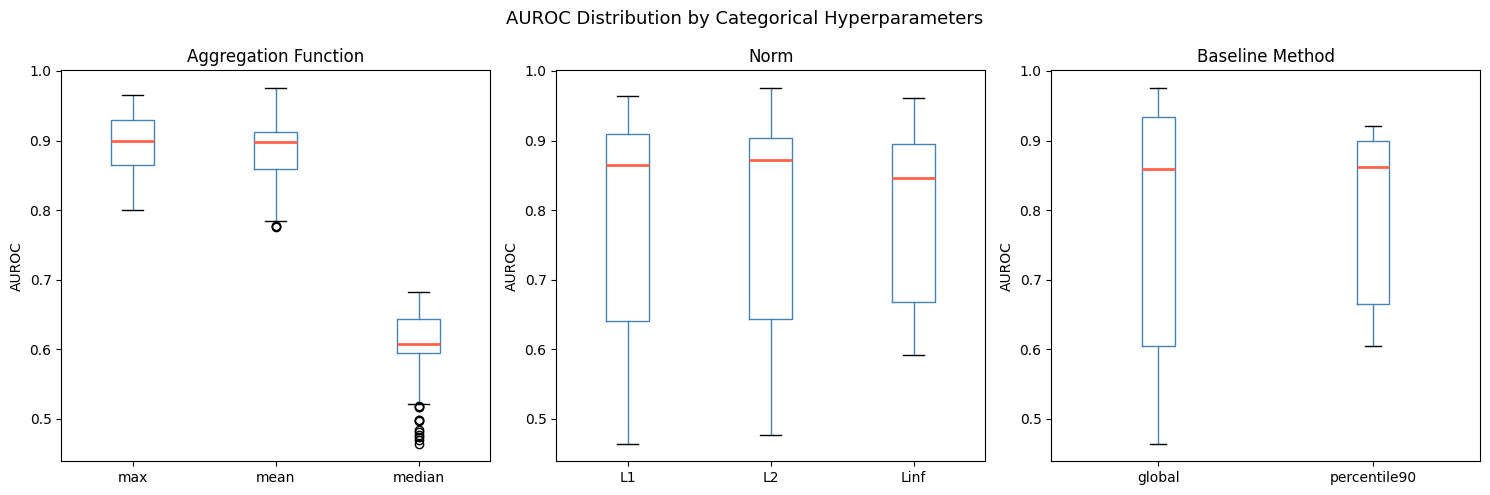

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, title in zip(
    axes,
    ['agg_fn', 'norm', 'baseline'],
    ['Aggregation Function', 'Norm', 'Baseline Method']
):
    grid_df.boxplot(column='AUROC', by=col, ax=ax, grid=False,
                    boxprops=dict(color='steelblue'),
                    whiskerprops=dict(color='steelblue'),
                    medianprops=dict(color='tomato', linewidth=2))
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel('AUROC')

fig.suptitle('AUROC Distribution by Categorical Hyperparameters', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Best Config

In [16]:
best_row = grid_df.loc[grid_df['AUROC'].idxmax()]

print('=== Best configuration by AUROC ===')
for k, v in best_row.items():
    if k not in ('run_name',):
        print(f'  {k:15s}: {v}')

# Re-score with best config
BEST_W    = int(best_row['W'])
BEST_STEP = int(best_row['step'])
BEST_AGG  = best_row['agg_fn']
BEST_NORM = best_row['norm']
BEST_BASE = best_row['baseline']

W_test_best   = make_windows(X_test_scaled, BEST_W, BEST_STEP)
y_w_best      = window_labels(y_bin_test, BEST_W, BEST_STEP, mode='any')
y_15c_w_best   = window_attack_types(y_15c_test, y_bin_test, BEST_W, BEST_STEP)

bm_best, bs_best = baselines[BEST_BASE]
best_scores = compute_sws_scores(W_test_best, bm_best, bs_best,
                                  agg_fn=BEST_AGG, norm=BEST_NORM)

best_res = evaluate(
    f'SWS (W={BEST_W}, step={best_row["step_name"]}, '
    f'agg={BEST_AGG}, norm={BEST_NORM}, base={BEST_BASE})',
    y_w_best, best_scores
)

BEST_THRESH = best_res['threshold']

=== Best configuration by AUROC ===
  W              : 520
  step_name      : full
  step           : 520
  agg_fn         : mean
  norm           : L2
  baseline       : global
  n_windows      : 826
  attack_rate    : 0.7578692493946732
  AUROC          : 0.9753753993610224
  AUPRC          : 0.9934108482876975
  F1             : 0.96826688364524
  Precision      : 0.9867330016583747
  Recall         : 0.950479233226837
  threshold      : 0.5946188561810029
  SWS (W=520, step=full, agg=mean, norm=L2, base=global)  AUROC=0.9754  AUPRC=0.9934  F1=0.9683


### ROC and Precision/Recall Curves

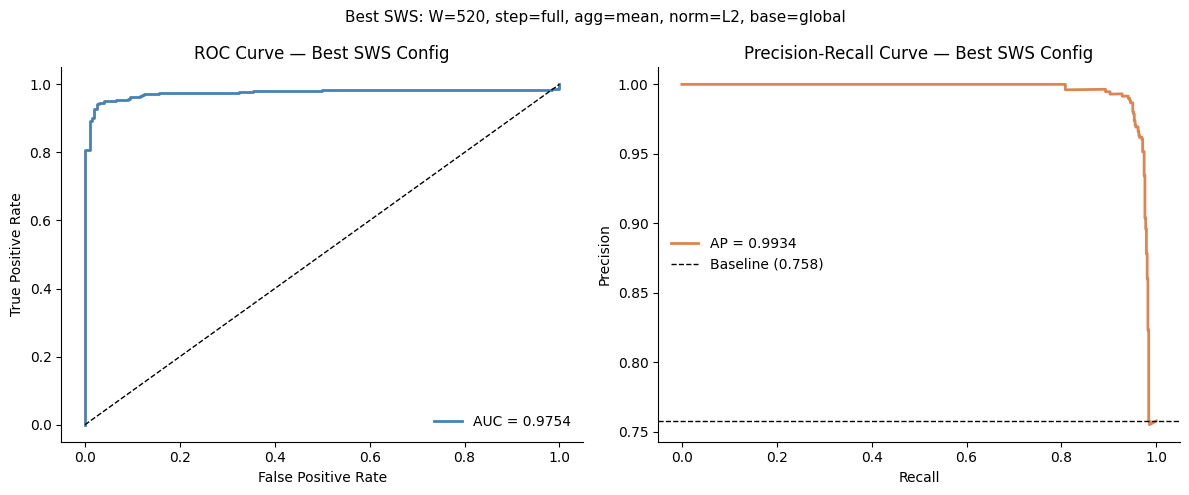

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
fpr, tpr, _ = roc_curve(y_w_best, best_scores)
ax.plot(fpr, tpr, color='steelblue', lw=2,
        label=f"AUC = {best_res['AUROC']:.4f}")
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Best SWS Config')
ax.legend(fontsize=10, frameon=False)
sns.despine(ax=ax)

ax = axes[1]
p, r, _ = precision_recall_curve(y_w_best, best_scores)
baseline_rate = y_w_best.mean()
ax.plot(r, p, color='#DD8452', lw=2,
        label=f"AP = {best_res['AUPRC']:.4f}")
ax.axhline(baseline_rate, color='k', linestyle='--', lw=1,
           label=f'Baseline ({baseline_rate:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve — Best SWS Config')
ax.legend(fontsize=10, frameon=False)
sns.despine(ax=ax)

plt.suptitle(
    f'Best SWS: W={BEST_W}, step={best_row["step_name"]}, '
    f'agg={BEST_AGG}, norm={BEST_NORM}, base={BEST_BASE}',
    fontsize=11
)
plt.tight_layout()
plt.show()

### Anomaly score timeline

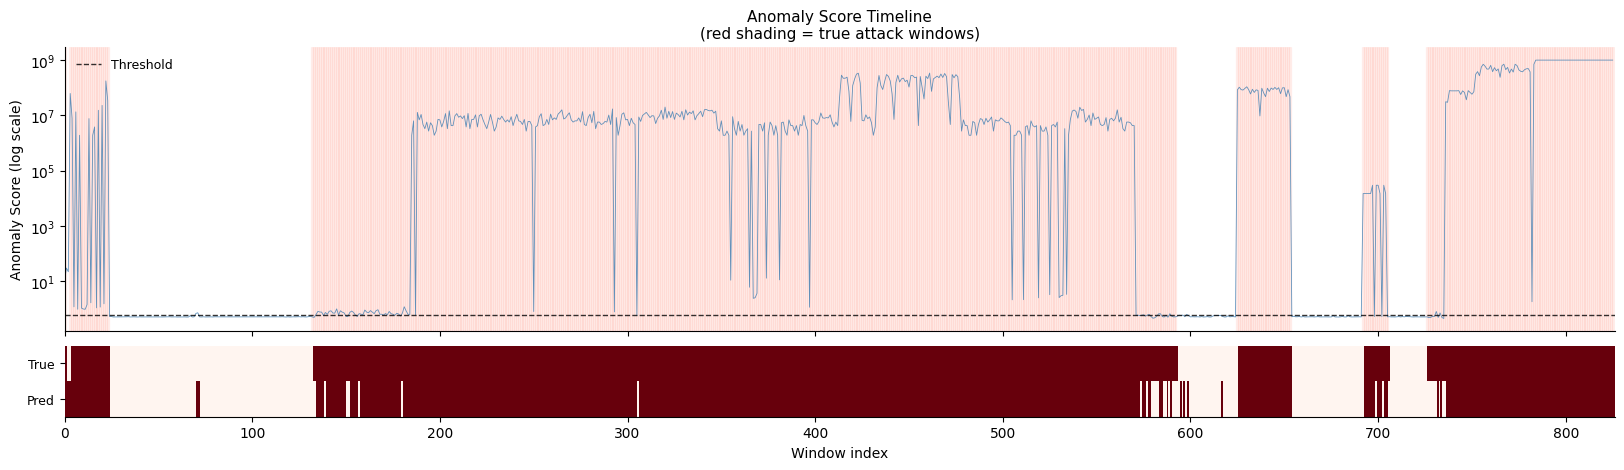

In [18]:
y_pred_best = (best_scores >= BEST_THRESH).astype(int)   # per-window predictions

fig, (ax, ax2) = plt.subplots(
    2, 1, figsize=(20, 4.8),
    gridspec_kw={'height_ratios': [4, 1], 'hspace': 0.08},
    sharex=True)

# (top) anomaly score timeline
ax.plot(best_scores, lw=0.6, color='steelblue', alpha=0.85)
ax.axhline(BEST_THRESH, color='black', linestyle='--', lw=1,
           alpha=0.8, label='Threshold')

for idx in np.where(y_w_best == 1)[0]:
    ax.axvspan(idx - 0.5, idx + 0.5, color='tomato', alpha=0.08)

ax.set_yscale('log')
ax.set_ylabel('Anomaly Score (log scale)')
ax.set_title('Anomaly Score Timeline\n'
             '(red shading = true attack windows)',
             fontsize=11)
ax.legend(fontsize=9, frameon=False)
ax.tick_params(labelbottom=False)

# (bottom) true vs predicted
strip = np.vstack([y_w_best, y_pred_best])          # row 0 = truth, row 1 = pred
ax2.imshow(strip, aspect='auto', cmap='Reds',
           interpolation='nearest', vmin=0, vmax=1,
           extent=[0, len(y_w_best), 0, 2])
ax2.set_yticks([0.5, 1.5])
ax2.set_yticklabels(['Pred', 'True'], fontsize=9)   # imshow row 0 at top
ax2.set_xlabel('Window index')

sns.despine(ax=ax)
sns.despine(ax=ax2, left=True)
plt.tight_layout()
plt.show()

### Confusion matrix

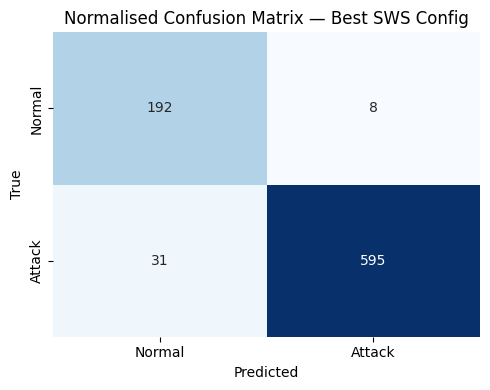

In [19]:
y_pred_best = (best_scores >= BEST_THRESH).astype(int)
cm = confusion_matrix(y_w_best, y_pred_best)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'], cbar=False)
ax.set_title('Normalised Confusion Matrix — Best SWS Config')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.tight_layout()
plt.show()

### Per-Attack-Type Recall

In [20]:
attack_types   = np.unique(y_15c_w_best[y_w_best == 1])
breakdown_rows = []

for atype in attack_types:
    mask = (y_15c_w_best == atype) & (y_w_best == 1)
    n    = mask.sum()
    if n == 0:
        continue
    recall = y_pred_best[mask].sum() / n
    breakdown_rows.append({'Attack Type': atype, 'Recall': recall, 'N windows': int(n)})

breakdown_df = pd.DataFrame(breakdown_rows).sort_values('Recall', ascending=False)
print('Per-attack-type recall (best SWS configuration):')
print(breakdown_df.to_string(index=False, float_format='{:.3f}'.format))

Per-attack-type recall (best SWS configuration):
          Attack Type  Recall  N windows
            DDoS_HTTP   1.000         19
             DDoS_TCP   1.000         36
            DDoS_ICMP   1.000         29
             DDoS_UDP   1.000         42
             Password   1.000        187
                  XSS   1.000         16
Vulnerability_scanner   1.000         47
            Uploading   1.000         17
        SQL_injection   1.000         29
        Port_Scanning   0.965         86
             Backdoor   0.817         71
       Fingerprinting   0.786         14
           Ransomware   0.636         33


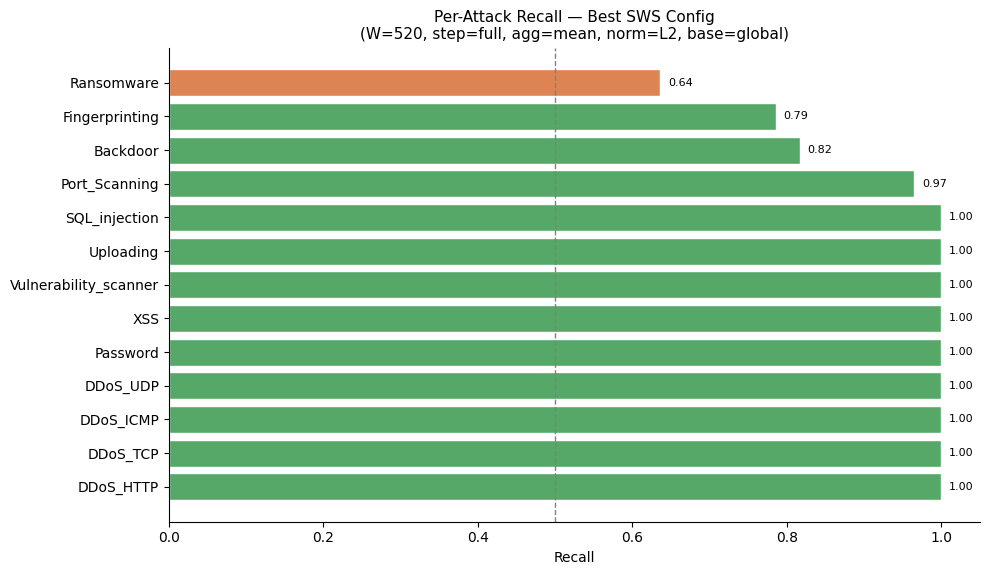

In [21]:
fig, ax = plt.subplots(figsize=(10, max(4, len(breakdown_df) * 0.45)))

colors_bar = ['#55A868' if r >= 0.7 else ('#DD8452' if r >= 0.4 else '#C44E52')
              for r in breakdown_df['Recall']]

ax.barh(breakdown_df['Attack Type'], breakdown_df['Recall'],
        color=colors_bar, edgecolor='white')
ax.axvline(0.5, color='gray', linestyle='--', lw=1)
ax.set_xlim(0, 1.05)
ax.set_xlabel('Recall')
ax.set_title(f'Per-Attack Recall — Best SWS Config\n'
             f'(W={BEST_W}, step={best_row["step_name"]}, agg={BEST_AGG}, '
             f'norm={BEST_NORM}, base={BEST_BASE})',
             fontsize=11)

for i, (_, row) in enumerate(breakdown_df.iterrows()):
    ax.text(row['Recall'] + 0.01, i, f"{row['Recall']:.2f}",
            va='center', fontsize=8)

sns.despine(ax=ax)
plt.tight_layout()
plt.show()

## 6. Final Summary

In [22]:
best_by = {
    'AUROC':     grid_df.loc[grid_df['AUROC'].idxmax()],
    'AUPRC':     grid_df.loc[grid_df['AUPRC'].idxmax()],
    'F1':        grid_df.loc[grid_df['F1'].idxmax()],
    'Recall':    grid_df.loc[grid_df['Recall'].idxmax()],
    'Precision': grid_df.loc[grid_df['Precision'].idxmax()],
}

print('=' * 70)
print('  SWS HYPERPARAMETER SEARCH — FULL DATASET')
print('=' * 70)
print(f'  Total configurations evaluated : {len(grid_df)}')
print(f'  Test windows                   : {len(y_w_best):,}')
print(f'  Attack rate (test windows)     : {y_w_best.mean():.3f}')
print(f'  Features                       : {X_train_scaled.shape[1]}')
print()

for metric, row in best_by.items():
    print(f'  Best by {metric:12s}: '
          f'W={int(row["W"])}, step={row["step_name"]}, '
          f'agg={row["agg_fn"]}, norm={row["norm"]}, base={row["baseline"]}  '
          f'→ {metric}={row[metric]:.4f}')

print()
print('Top-10 by AUROC:')
print(
    grid_df.nlargest(10, 'AUROC')[
        ['W', 'step_name', 'agg_fn', 'norm', 'baseline',
         'AUROC', 'AUPRC', 'F1', 'Precision', 'Recall']
    ].to_string(index=False, float_format='{:.4f}'.format)
)

  SWS HYPERPARAMETER SEARCH — FULL DATASET
  Total configurations evaluated : 378
  Test windows                   : 826
  Attack rate (test windows)     : 0.758
  Features                       : 43

  Best by AUROC       : W=520, step=full, agg=mean, norm=L2, base=global  → AUROC=0.9754
  Best by AUPRC       : W=520, step=full, agg=mean, norm=L2, base=global  → AUPRC=0.9934
  Best by F1          : W=520, step=full, agg=mean, norm=Linf, base=global  → F1=0.9715
  Best by Recall      : W=20, step=full, agg=median, norm=L1, base=global  → Recall=1.0000
  Best by Precision   : W=520, step=full, agg=mean, norm=Linf, base=global  → Precision=0.9917

Top-10 by AUROC:
  W step_name agg_fn norm baseline  AUROC  AUPRC     F1  Precision  Recall
520      full   mean   L2   global 0.9754 0.9934 0.9683     0.9867  0.9505
520   quarter   mean   L2   global 0.9742 0.9932 0.9669     0.9843  0.9501
520      half   mean   L2   global 0.9738 0.9931 0.9675     0.9867  0.9489
320   quarter   mean   L2   g

## 7. Save Results

In [23]:
import joblib
from pathlib import Path

out_path = config['bin_model_path'] / 'sws_search'
out_path.mkdir(parents=True, exist_ok=True)

grid_df.drop(columns=['run_name']).to_csv(
    out_path / 'sws_grid_results.csv', index=False
)

joblib.dump(scaler, out_path / 'SWS_num_scaler.pkl')

joblib.dump(
    {"mean": bm_best, "std": bs_best},
    out_path / "SWS_num_baseline.joblib",
)

print(f'Results saved to: {out_path}')

Results saved to: C:\Users\angel\Documents\ML-NIDS-IIoT\models\edge_iiot\binary\sws_search
